In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv('orders_raw.csv')
products = pd.read_csv('products.csv')
print(orders.shape)
print(products.shape)

orders.head()

(508, 11)
(31, 5)


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0


In [2]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [3]:
orders.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [4]:
orders['status'].value_counts()

status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

In [5]:
def audit(df):
    # One row per column: type, missingness, cardinality, sample value
    return pd.DataFrame({
        'dtype':   df.dtypes.astype(str),
        'nulls':   df.isnull().sum(),
        'null_%':  (df.isnull().mean() * 100).round(1),
        'unique':  df.nunique(),
        'example': df.iloc[0].astype(str).str.slice(0, 20),
    })

audit(orders)

,dtype,nulls,null_%,unique,example
order_id,int64,0,0.0,500,1
order_date,str,0,0.0,165,2026-03-09
customer_name,str,0,0.0,50,Dev
city,str,0,0.0,14,Pune
category,str,0,0.0,18,Snacks & Beverages
product_id,int64,0,0.0,30,13
quantity,int64,0,0.0,5,5
amount_inr,float64,10,2.0,88,175.0
payment_mode,str,0,0.0,5,UPI
status,str,0,0.0,3,Delivered


In the orders data frame **amount_inr** column has 10 and **rating** column has 69 missing/null value

**order_date** column is object data type instent of date formate

**order_id** has total 500 unique value across 508, 8 rows are reapting

In **city** and **category** has toatl 4 and 6 unique value respectively as per data set but here due to consistency issue values is unexpected that is 14 and 18 respectively

In [6]:
orders = orders.drop_duplicates(subset = 'order_id', keep = 'first')
print(orders.shape)

(500, 11)


Total 8 repated rows are removed from orders data set

In [7]:
orders['city'].value_counts()

city
Mumbai         131
Hyderabad      130
Bengaluru      111
Pune           108
 Bengaluru       3
MUMBAI           3
BENGALURU        2
 Mumbai          2
HYDERABAD        2
mumbai           2
 Pune            2
 Hyderabad       2
bengaluru        1
PUNE             1
Name: count, dtype: int64

In [8]:
orders['category'].value_counts()

category
Snacks & Beverages        93
Household Essentials      93
Fruits & Vegetables       78
Bakery                    76
Dairy & Eggs              71
Personal Care             69
 Dairy & Eggs              3
BAKERY                     3
DAIRY & EGGS               2
 Bakery                    2
dairy & eggs               2
HOUSEHOLD ESSENTIALS       2
 Household Essentials      1
SNACKS & BEVERAGES         1
 Personal Care             1
FRUITS & VEGETABLES        1
 Fruits & Vegetables       1
snacks & beverages         1
Name: count, dtype: int64

In [9]:
orders['category'] = orders['category'].str.strip().str.title()
orders['category'].value_counts()

category
Household Essentials    96
Snacks & Beverages      95
Bakery                  81
Fruits & Vegetables     80
Dairy & Eggs            78
Personal Care           70
Name: count, dtype: int64

In [10]:
orders['city'] = orders['city'].str.strip().str.title()
orders['city'].value_counts()

city
Mumbai       138
Hyderabad    134
Bengaluru    117
Pune         111
Name: count, dtype: int64

In [11]:
missing_amount_count = orders['amount_inr'].isnull().sum()
print(f' The missing count in amount_inr column is {missing_amount_count}')

orders = orders.dropna(subset = ['amount_inr'])

 The missing count in amount_inr column is 10


The missing count in **amount_inr** column is 10
For Cancelled/Pending orders Keep the rating missing values as NaN

In [12]:
delivered_mask = orders['status'] == 'Delivered'

Q1 = orders['amount_inr'].quantile(0.25)
Q3 =  orders['amount_inr'].quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 1.5*IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Upper Fence: {upper_fence}")

# Count rows above the upper fence before capping
capped_count = (orders.loc[delivered_mask, 'amount_inr'] > upper_fence).sum()

# Cap outliers above upper fence
orders.loc[delivered_mask, 'amount_inr'] = orders.loc[delivered_mask, 'amount_inr'].clip(upper=upper_fence)

print(f"The total Capped count is {capped_count} outlier values at {upper_fence}")

Q1: 90.0, Q3: 280.0, IQR: 190.0
Upper Fence: 565.0
The total Capped count is 16 outlier values at 565.0


In [13]:
# Convert order_date to datetime format
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Extract month and month_name
orders['month'] = orders['order_date'].dt.month
orders['month_name'] = orders['order_date'].dt.month_name()

# Calculate revenue_per_unit
orders['revenue_per_unit'] = orders['amount_inr'] / orders['quantity']

# Create is_delivered column
orders['is_delivered'] = orders['status'] == 'Delivered'

In [14]:
orders.head()

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,month,month_name,revenue_per_unit,is_delivered
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,3,March,35.0,True
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,5,May,60.0,True
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,6,June,75.0,True
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,3,March,30.0,True
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,4,April,110.0,True


In [15]:
# inspection of product data frame
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product_id      31 non-null     int64
 1   product_name    31 non-null     str  
 2   category        31 non-null     str  
 3   supplier        31 non-null     str  
 4   unit_price_inr  31 non-null     int64
dtypes: int64(2), str(3)
memory usage: 1.3 KB


In [16]:
products.describe()

,product_id,unit_price_inr
count,31.000000,31.000000
mean,16.000000,91.677419
std,9.092121,81.635526
min,1.000000,20.000000
25%,8.500000,45.000000
50%,16.000000,70.000000
75%,23.500000,104.500000
max,31.000000,450.000000


In [17]:
def audit(df):
    # One row per column: type, missingness, cardinality, sample value
    return pd.DataFrame({
        'dtype':   df.dtypes.astype(str),
        'nulls':   df.isnull().sum(),
        'null_%':  (df.isnull().mean() * 100).round(1),
        'unique':  df.nunique(),
        'example': df.iloc[0].astype(str).str.slice(0, 20),
    })

audit(products)

,dtype,nulls,null_%,unique,example
product_id,int64,0,0.0,31,1
product_name,str,0,0.0,31,Banana 1kg
category,str,0,0.0,6,Fruits & Vegetables
supplier,str,0,0.0,8,FreshFarms Co
unit_price_inr,int64,0,0.0,26,50


In [18]:
# (a) Total revenue per category (Delivered orders only)

cat_revenue = orders[orders['status'] == 'Delivered'].groupby('category')['amount_inr'].sum().sort_values(ascending=False)

print(f"Total Revenue by Category (Delivered Only) is : {cat_revenue}")
top_category = cat_revenue.index[0]

Total Revenue by Category (Delivered Only) is : category
Household Essentials    20985.0
Bakery                  15000.0
Personal Care           14657.0
Dairy & Eggs            13675.0
Snacks & Beverages      11325.0
Fruits & Vegetables      9195.0
Name: amount_inr, dtype: float64


In [19]:
# (b) Merge with products.csv to get supplier revenue
merged_df = pd.merge(orders[orders['is_delivered']], products, on='product_id', how='left')
supplier_revenue = merged_df.groupby('supplier')['amount_inr'].sum().sort_values(ascending=False)

print(f"\n Total Revenue by Supplier (Delivered Only) {supplier_revenue}")
top_supplier = supplier_revenue.index[0]


 Total Revenue by Supplier (Delivered Only) supplier
HomeEssentials Traders    20985.0
BakeHouse Supplies        18575.0
CarePlus Distributors     14657.0
DairyBest Ltd             10710.0
SnackHub India             7750.0
FreshFarms Co              5490.0
GreenValley Traders        3705.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64


In [20]:
# (c) Cross-validation statement
print(f"\nTop Category: {top_category}")
print(f"Top Supplier: {top_supplier}")


Top Category: Household Essentials
Top Supplier: HomeEssentials Traders


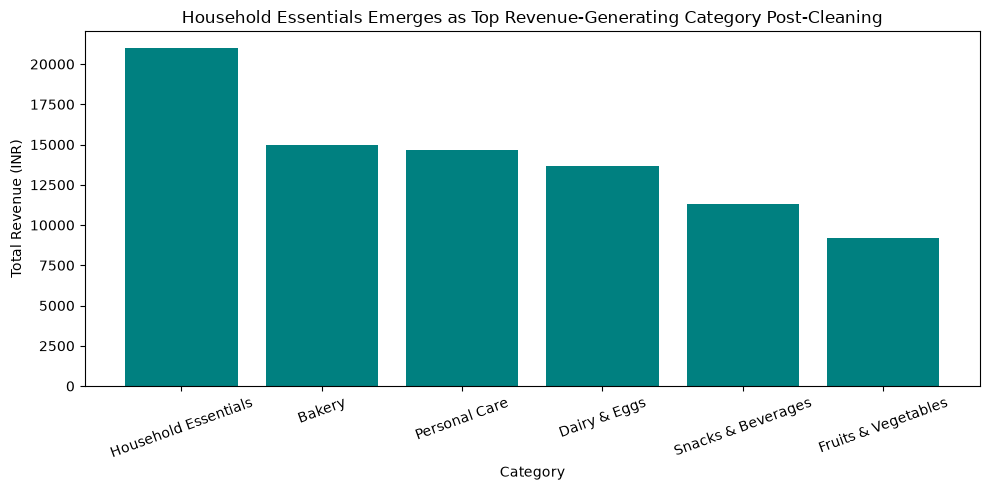

In [21]:
# Chart 1: Bar Chart of Category Revenue (Post-Cleaning)
plt.figure(figsize=(10, 5))
plt.bar(cat_revenue.index, cat_revenue.values, color="teal")
plt.title("Household Essentials Emerges as Top Revenue-Generating Category Post-Cleaning")
plt.xlabel("Category")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

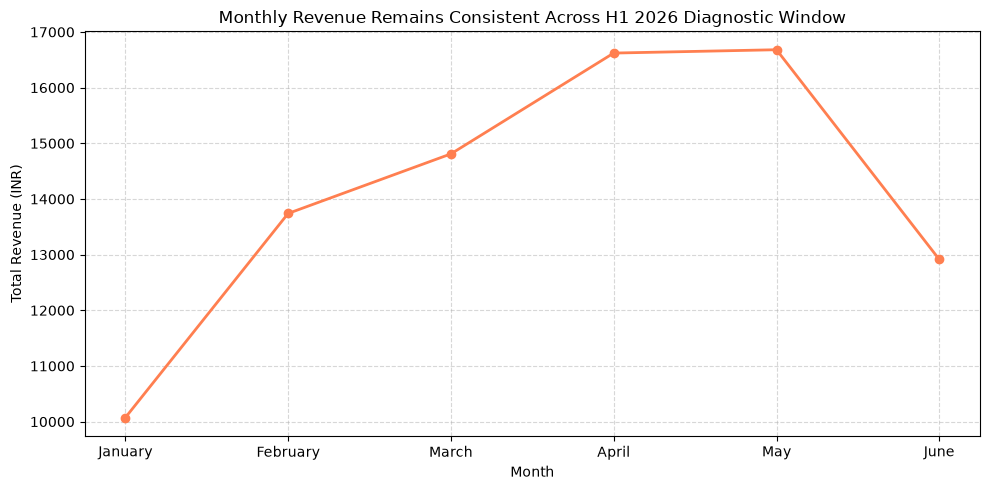

In [22]:
# Chart 2: Line Chart of Total Monthly Revenue Trend
monthly_revenue = (
    orders[orders['status'] == 'Delivered'].groupby(["month","month_name"])["amount_inr"]
    .sum()
    .reset_index()
    .sort_values("month")
)
monthly_revenue["month_name"] = monthly_revenue["month_name"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue["month_name"], monthly_revenue["amount_inr"], marker="o", color="coral", linewidth=2)
plt.title("Monthly Revenue Remains Consistent Across H1 2026 Diagnostic Window")
plt.xlabel("Month")
plt.ylabel("Total Revenue (INR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

###**Observations**

1. Household Essentials is the highest-performing category by revenue post-cleaning (₹21,715), Maintain inventory priority for key Household Essentials to safeguard high-margin revenue streams.
2. Fruits & Vegetables generated the lowest revenue (₹9,790), falling significantly short of its ₹12,000 monthly target, Despite high order frequency, low average item values prevent the category from hitting growth targets, Introduce bundled combo packs (e.g., weekly vegetable baskets) to increase unit basket size and average order value.
3. Data cleaning removed 8 duplicate rows, handled 10 missing revenue values, and capped outliers using an upper IQR fence, successfully maintaining categorical alignment with SQL outputs. 
